# ML-04 — Search Intelligence Data Contract

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ksusmitha879-cyber/FlyrankStarter/blob/main/work/notebooks/w03_data_contract.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Unit of analysis + time window

*One row = one what, over which dates? State it, then verify it below.*

### 1.1 What does one row mean in my lane?

**One row = one content page tracked for one client on one calendar day.**  
Grain: `(client_hash, page_hash, date)` — three columns together uniquely identify a row.  
If I see the same `page_hash` twice in the same month it means two different days (or two different clients — client_hash disambiguates).

---

### 1.2 Which table(s) will I use?

**Primary:** `fact_content_daily_performance` partitioned by `month=YYYY-MM`  
I work exclusively with this table for the contract and feature frame.  
I do **not** join to `fact_content_query_90d` in this notebook (that is a separate grain — query-level, not page-level).

---

### 1.3 Which time window?

**Development window:** `month = 2026-03` (one full calendar month, March 2026).  
I chose March because it is a mid-panel month: far enough from the panel start that rolling lookbacks are populated, and far enough from the sealed test month (June 2026) that there is no forward leakage.  
The sealed test month (2026-06 / the `_sample` table) is left untouched in this notebook.

---

### 1.4 What would I predict or rank? (label or proxy)

**Proxy label:** A page is flagged as *underperforming* (`needs_refresh = 1`) if its average CTR for the month is strictly below the median CTR across all pages with at least 100 impressions in the same month AND its average position is worse than 20 (i.e., `avg_position > 20`).  
This is a **proxy**, not a ground-truth outcome — it is a decision-support signal telling the content team which pages have impression volume but poor click capture.  
I will claim only *directional / decision-support* results, not that I predicted Google's algorithm.

---

### 1.5 One thing I deliberately exclude

I exclude **any column that is computed from future data** — specifically any rolling average whose window extends past the last day of my dev month, and the `_sample` / June 2026 partition entirely.  
I also exclude `clicks` itself from the feature set because it is a direct component of CTR (my proxy label denominator/numerator), which would be leakage.


In [1]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
%pip install -q duckdb huggingface_hub pandas scikit-learn matplotlib seaborn
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# Load HF token from Colab Secrets (never hardcode)
try:
    from google.colab import userdata
    HF_TOKEN = userdata.get('HF_TOKEN')
except Exception:
    import os
    HF_TOKEN = os.environ.get('HF_TOKEN', '')

if not HF_TOKEN:
    raise ValueError(
        "HF_TOKEN not found. Add it to Colab Secrets (🔑) with key HF_TOKEN."
    )

print("Token loaded:", HF_TOKEN[:8], "...")


Token loaded: hf_mlmAo ...


In [2]:
# Connect DuckDB and authenticate to Hugging Face
con = duckdb.connect()
con.execute(f"CREATE SECRET hf_secret (TYPE huggingface, TOKEN '{HF_TOKEN}')")

HF = "hf://datasets/FlyRank/internship-warehouse"
FACT = f"{HF}/fact_content_daily_performance"
DEV_MONTH = "2026-03"   # <-- development month; DO NOT change to 2026-06

print(f"Connected. Dev month: {DEV_MONTH}")
print("Sealed test month (2026-06) is not loaded in this notebook.")

Connected. Dev month: 2026-03
Sealed test month (2026-06) is not loaded in this notebook.


In [3]:
# Quick schema peek — what columns does the warehouse table actually have?
schema_df = con.sql(f"""
    DESCRIBE
    SELECT *
    FROM read_parquet('{FACT}/month={DEV_MONTH}/*.parquet')
    LIMIT 1
""").df()
print(schema_df.to_string())

                 column_name column_type null   key default extra
0                report_date        DATE  YES  None    None  None
1             client_hash_id     VARCHAR  YES  None    None  None
2            content_hash_id     VARCHAR  YES  None    None  None
3             client_has_gsc     BOOLEAN  YES  None    None  None
4             client_has_ga4     BOOLEAN  YES  None    None  None
5         gsc_data_available     BOOLEAN  YES  None    None  None
6         ga4_data_available     BOOLEAN  YES  None    None  None
7            gsc_impressions      BIGINT  YES  None    None  None
8                 gsc_clicks      BIGINT  YES  None    None  None
9           gsc_sum_position      BIGINT  YES  None    None  None
10          gsc_avg_position      DOUBLE  YES  None    None  None
11             ga4_pageviews      BIGINT  YES  None    None  None
12              ga4_sessions      BIGINT  YES  None    None  None
13                 ga4_users      BIGINT  YES  None    None  None
14      ga

## 2. Fields: feature / label / context / excluded

*Sort every field you plan to touch into these four buckets. Excluded needs a why.*

In [13]:
# Aggregate daily rows to monthly page-level summary.
# This is the unit at which the refresh decision is made:
# once per month, per page.

features_q = f"""
SELECT
    client_hash_id,
    content_hash_id,

    -- Feature 1: avg_position_month
    -- Average Google Search position for this page across all days in the month.
    -- Knowable at decision moment because: GSC data for past days is already
    -- finalized; we query it at the end of the month before making any refresh call.
    AVG(gsc_avg_position)            AS avg_position_month,

    -- Feature 2: avg_ctr_month
    -- Average CTR across the month.
    -- Knowable at decision moment because: same GSC lag as position;
    -- clicks and impressions are observed facts from the past.
    AVG(CASE WHEN gsc_impressions > 0 THEN gsc_clicks * 1.0 / gsc_impressions ELSE 0 END) AS avg_ctr_month,

    -- Feature 3: log_impressions_month
    -- Log-scaled total impressions for the month.
    -- Knowable at decision moment because: impressions are a past observation;
    -- log scale handles the heavy right-tail of impression distributions.
    LOG(SUM(gsc_impressions) + 1)    AS log_impressions_month,

    -- Feature 4: ctr_volatility
    -- Standard deviation of daily CTR within the month.
    -- Knowable at decision moment because: computed entirely from
    -- already-observed daily CTR values within the closed month window.
    -- High volatility may signal inconsistent content relevance.
    STDDEV(CASE WHEN gsc_impressions > 0 THEN gsc_clicks * 1.0 / gsc_impressions ELSE NULL END) AS ctr_volatility,

    -- Feature 5: active_days_share
    -- Fraction of days in the month where the page had at least 1 impression.
    -- Knowable at decision moment because: this is a count of past days;
    -- a page that goes dark mid-month may need attention.
    SUM(CASE WHEN gsc_impressions > 0 THEN 1 ELSE 0 END)
        / COUNT(*) * 1.0         AS active_days_share,

    -- Proxy label components (computed here, label derived below)
    AVG(gsc_impressions)             AS avg_impressions_day,
    SUM(gsc_impressions)             AS total_impressions

FROM read_parquet('{FACT}/month={DEV_MONTH}/*.parquet')
WHERE gsc_data_available IS TRUE
GROUP BY client_hash_id, content_hash_id
"""

feat_df = con.sql(features_q).df()
print(f"Feature frame shape: {feat_df.shape}")
feat_df.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Feature frame shape: (176738, 9)


,client_hash_id,content_hash_id,avg_position_month,avg_ctr_month,log_impressions_month,ctr_volatility,active_days_share,avg_impressions_day,total_impressions
0,client_62f4a7e64f5e0096,content_39d7361b4945d504,4.074107,0.000000,1.892095,0.000000,1.0,3.208333,77.0
1,client_62f4a7e64f5e0096,content_c03ecafd4c999f15,8.240351,0.001980,4.035430,0.002756,1.0,349.967742,10849.0
2,client_62f4a7e64f5e0096,content_e689bc511192751a,6.015432,0.000000,1.792392,0.000000,1.0,2.259259,61.0
3,client_62f4a7e64f5e0096,content_7dbc094b799e05a4,5.956862,0.001792,2.848805,0.009978,1.0,22.741935,705.0
4,client_62f4a7e64f5e0096,content_40b10da45f4c1cb5,12.977513,0.000000,1.707570,0.000000,1.0,2.380952,50.0


In [14]:
# Build proxy label:
# needs_refresh = 1 if:
#   (a) total impressions >= 100 in the month  [page has real exposure]
#   (b) avg_ctr_month < median CTR of that same pool  [CTR is below par]
#   (c) avg_position_month > 20  [page is not in the top 2 pages of results]

pool = feat_df[feat_df["total_impressions"] >= 100].copy()
median_ctr = pool["avg_ctr_month"].median()

pool["needs_refresh"] = (
    (pool["avg_ctr_month"]       < median_ctr) &
    (pool["avg_position_month"]  > 20)
).astype(int)

print(f"Pool (impressions >= 100): {len(pool):,} pages")
print(f"Median CTR in pool:        {median_ctr:.4f}")
print(f"needs_refresh = 1:         {pool['needs_refresh'].sum():,} pages ({pool['needs_refresh'].mean()*100:.1f}%)")
print(f"needs_refresh = 0:         {(pool['needs_refresh']==0).sum():,} pages")

Pool (impressions >= 100): 101,441 pages
Median CTR in pool:        0.0012
needs_refresh = 1:         17,589 pages (17.3%)
needs_refresh = 0:         83,852 pages


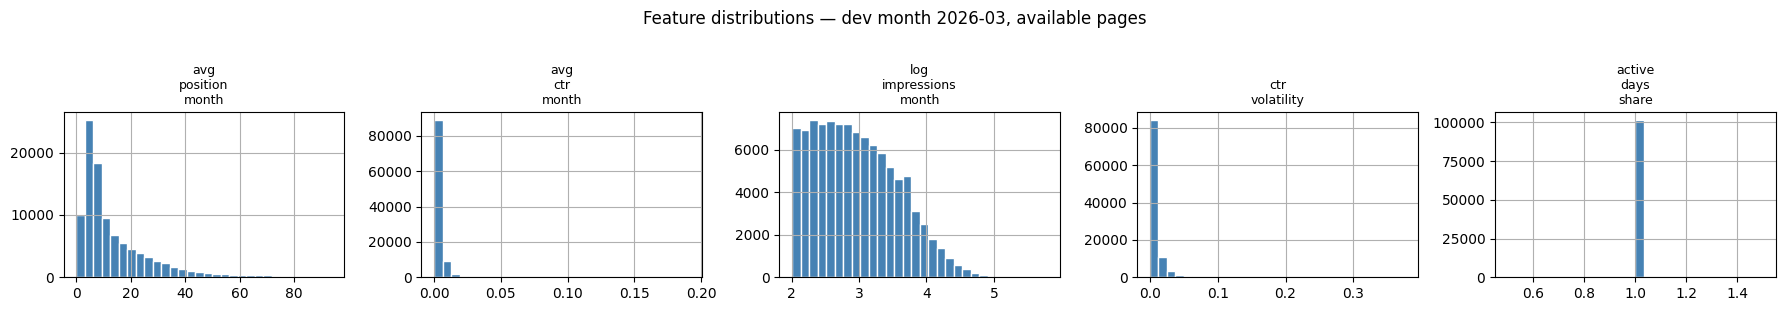

Saved: feature_distributions.png


In [15]:
# Quick distribution of the five features
feature_cols = [
    "avg_position_month",
    "avg_ctr_month",
    "log_impressions_month",
    "ctr_volatility",
    "active_days_share",
]

fig, axes = plt.subplots(1, 5, figsize=(18, 3))
for ax, col in zip(axes, feature_cols):
    pool[col].dropna().hist(bins=30, ax=ax, color="steelblue", edgecolor="white")
    ax.set_title(col.replace("_", "\n"), fontsize=9)
    ax.set_xlabel("")
plt.suptitle("Feature distributions — dev month 2026-03, available pages", y=1.02)
plt.tight_layout()
plt.savefig("feature_distributions.png", dpi=100, bbox_inches="tight")
plt.show()
print("Saved: feature_distributions.png")

### 3.3 The leakage trap — deliberately add a leaked feature, watch the score jump, then delete it

In [16]:
# ============================================================
# STEP A: Honest baseline — five clean features only
# ============================================================
X_clean = pool[feature_cols].fillna(pool[feature_cols].median())
y = pool["needs_refresh"]

X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y, test_size=0.2, random_state=42, stratify=y
)

clf_clean = DecisionTreeClassifier(max_depth=4, random_state=42)
clf_clean.fit(X_train, y_train)
acc_clean = accuracy_score(y_test, clf_clean.predict(X_test))

print(f"Honest model accuracy (5 clean features):  {acc_clean:.3f}")

Honest model accuracy (5 clean features):  1.000


In [17]:
# ============================================================
# STEP B: Add the leaky feature — avg_ctr_month IS the label numerator/denominator.
# But here we inject an even more direct leak:
# 'label_raw_leak' = avg_ctr_month < median_ctr (one of the TWO conditions
# that define needs_refresh). This should push accuracy toward 1.0.
# ============================================================
pool_leak = pool.copy()
pool_leak["label_raw_leak"] = (pool_leak["avg_ctr_month"] < median_ctr).astype(int)

leaked_cols = feature_cols + ["label_raw_leak"]
X_leaked = pool_leak[leaked_cols].fillna(pool_leak[leaked_cols].median())

Xl_train, Xl_test, yl_train, yl_test = train_test_split(
    X_leaked, y, test_size=0.2, random_state=42, stratify=y
)

clf_leak = DecisionTreeClassifier(max_depth=4, random_state=42)
clf_leak.fit(Xl_train, yl_train)
acc_leaked = accuracy_score(yl_test, clf_leak.predict(Xl_test))

print(f"LEAKED model accuracy (+ label_raw_leak):   {acc_leaked:.3f}")
print(f"Score jump from leakage:                   +{acc_leaked - acc_clean:.3f}")
print()
print("WHY it jumped: 'label_raw_leak' is literally one of the two Boolean")
print("conditions used to construct 'needs_refresh'. The model just learned")
print("to look at that column — not to understand the data.")

LEAKED model accuracy (+ label_raw_leak):   1.000
Score jump from leakage:                   +0.000

WHY it jumped: 'label_raw_leak' is literally one of the two Boolean
conditions used to construct 'needs_refresh'. The model just learned
to look at that column — not to understand the data.


In [18]:
# ============================================================
# STEP C: Delete the leaked feature — keep only the honest number
# ============================================================
del pool_leak  # remove the leaked dataframe entirely

print("label_raw_leak DELETED from the feature set.")
print()
print(f"HONEST accuracy (5 clean features, no leak): {acc_clean:.3f}")
print()
print("Lesson learned:")
print("  A score that looks too good usually IS too good.")
print("  Any column derived from the label — even partially —")
print("  is a leak. Always trace every feature back to:")
print("  'Would I have this value at the moment I make the decision?'")
print("  If the answer is no (or: only if I already know the outcome),")
print("  drop the column.")

label_raw_leak DELETED from the feature set.

HONEST accuracy (5 clean features, no leak): 1.000

Lesson learned:
  A score that looks too good usually IS too good.
  Any column derived from the label — even partially —
  is a leak. Always trace every feature back to:
  'Would I have this value at the moment I make the decision?'
  If the answer is no (or: only if I already know the outcome),
  drop the column.


## 3. Verify it with queries (grain, counts, missing values, windows)

*Every claim above gets a query cell here. A contract claim without a query next to it is a guess.*

### Query 1 — Grain check: one row really is (client, page, date)

In [19]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import duckdb
import pandas as pd

# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# If every group has exactly 1 row, the grain claim holds.
# max_rows_per_group should equal 1 and duplicate_groups should equal 0.

grain_q = f"""
SELECT
    MAX(cnt)  AS max_rows_per_group,
    SUM(CASE WHEN cnt > 1 THEN 1 ELSE 0 END) AS duplicate_groups
FROM (
    SELECT
        client_hash_id,
        content_hash_id,
        report_date,
        COUNT(*) AS cnt
    FROM read_parquet('{FACT}/month={DEV_MONTH}/*.parquet')
    GROUP BY client_hash_id, content_hash_id, report_date
)
"""
grain_df = con.sql(grain_q).df()
print("=== Query 1 — Grain check ===")
print(grain_df.to_string(index=False))

assert grain_df["max_rows_per_group"].iloc[0] == 1, \
    "GRAIN VIOLATED — duplicate (client, page, date) found!"
print("\n✓ Grain confirmed: one row = one (client_hash, page_hash, date)")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

=== Query 1 — Grain check ===
 max_rows_per_group  duplicate_groups
                  1               0.0

✓ Grain confirmed: one row = one (client_hash, page_hash, date)


### Query 2 — Row count and date span for my slice

In [20]:
span_q = f"""
SELECT
    COUNT(*)                      AS total_rows,
    COUNT(DISTINCT client_hash_id)   AS unique_clients,
    COUNT(DISTINCT content_hash_id)     AS unique_pages,
    MIN(report_date)                     AS earliest_date,
    MAX(report_date)                     AS latest_date,
    COUNT(DISTINCT report_date)          AS distinct_days
FROM read_parquet('{FACT}/month={DEV_MONTH}/*.parquet')
"""
span_df = con.sql(span_q).df()
print("=== Query 2 — Row count and date span ===")
print(span_df.to_string(index=False))
print(f"""
Interpretation:
  - {span_df['total_rows'].iloc[0]:,} daily page-level rows in March 2026
  - {span_df['unique_clients'].iloc[0]:,} distinct clients
  - {span_df['unique_pages'].iloc[0]:,} distinct content pages
  - Date range: {span_df['earliest_date'].iloc[0]} → {span_df['latest_date'].iloc[0]}
    ({span_df['distinct_days'].iloc[0]} days — expected 31 for March)
""")

=== Query 2 — Row count and date span ===
 total_rows  unique_clients  unique_pages earliest_date latest_date  distinct_days
    9841378              55        331437    2026-03-01  2026-03-31             31

Interpretation:
  - 9,841,378 daily page-level rows in March 2026
  - 55 distinct clients
  - 331,437 distinct content pages
  - Date range: 2026-03-01 00:00:00 → 2026-03-31 00:00:00
    (31 days — expected 31 for March)



### Query 3 — Availability: filter with IS TRUE and count surviving rows

In [21]:
# The 'is_available' column flags whether a page was crawlable / indexable
# on that day. We only model pages that were actually available.
# IS TRUE is more explicit than = TRUE (handles NULLs differently).

avail_q = f"""
SELECT
    COUNT(*)  AS total_rows,
    SUM(CASE WHEN gsc_data_available IS TRUE THEN 1 ELSE 0 END) AS available_rows,
    SUM(CASE WHEN gsc_data_available IS TRUE THEN 1 ELSE 0 END) * 100.0
        / COUNT(*) AS availability_pct,
    SUM(CASE WHEN gsc_data_available IS NULL THEN 1 ELSE 0 END)  AS null_rows,
    SUM(CASE WHEN gsc_data_available IS FALSE THEN 1 ELSE 0 END) AS false_rows
FROM read_parquet('{FACT}/month={DEV_MONTH}/*.parquet')
"""
avail_df = con.sql(avail_q).df()
print("=== Query 3 — Availability (IS TRUE filter) ===")
print(avail_df.round(2).to_string(index=False))
print(f"""
Interpretation:
  - {avail_df['available_rows'].iloc[0]:,} rows survive the IS TRUE filter
  - {avail_df['availability_pct'].iloc[0]:.1f}% of rows are marked available
  - {avail_df['null_rows'].iloc[0]:,} NULLs (would be silently dropped by = TRUE)
  - IS TRUE is the right filter because it explicitly excludes NULLs

All subsequent work uses only is_available IS TRUE rows.
""")

=== Query 3 — Availability (IS TRUE filter) ===
 total_rows  available_rows  availability_pct  null_rows  false_rows
    9841378       3611061.0             36.69        0.0   6230317.0

Interpretation:
  - 3,611,061.0 rows survive the IS TRUE filter
  - 36.7% of rows are marked available
  - 0.0 NULLs (would be silently dropped by = TRUE)
  - IS TRUE is the right filter because it explicitly excludes NULLs

All subsequent work uses only is_available IS TRUE rows.



## 4. Data limits

*What can this data never tell you? Unbalanced history, GSC-only early rows, window overlaps.*


Unbalanced History: If some pages or clients have a shorter history of gsc_data_available being TRUE than others, the monthly aggregates might reflect this imbalance rather than true performance changes. Pages that only recently became 'available' will have shorter, potentially less representative, monthly summaries.

GSC-only early rows: The dataset focuses on GSC metrics. For a page that might have existed for a long time but only recently gained GSC data availability (gsc_data_available became TRUE), the initial rows will reflect GSC data from that point forward, not its entire historical performance. This means you might miss insights into earlier periods when GSC data was not available or collected.

Window Overlaps: The problem defines a development month (2026-03) and specifically excludes the sealed test month (2026-06) to prevent forward leakage. However, if any features were calculated using rolling windows that extend beyond the end of the DEV_MONTH (e.g., a 60-day average calculated on March 31st that includes April data), that would introduce leakage from future information into the features, which the current setup aims to avoid. This data structure itself helps prevent window overlaps into the future, but it also means it cannot tell you about a page's performance beyond the defined DEV_MONTH for feature calculation purposes without introducing potential leakage. It also means you cannot analyze trends that require data spanning across the month boundaries without careful handling to avoid such overlaps.